# Features Generation Validation Analysis: Variability and Accuracy of the Predictions

In [29]:
import os
import json
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
import numpy as np
from sklearn.metrics import accuracy_score, mean_absolute_error, confusion_matrix

In [30]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')
sys.path.append(project_path)
validation_results_dir = os.path.join(project_path, 'data', 'validation_results')

from config.config_03bcd_04bc import (
    FEATURE_CONFIG
)

feature_names = FEATURE_CONFIG.keys()

In [31]:
true_predicted_values_df, df_plot = {}, {}

for feature_name in FEATURE_CONFIG.keys():

    try:
        true_predicted_values_df_path = os.path.join(validation_results_dir, f'true_predicted_values_{feature_name}.parquet')
        df_plot_path = os.path.join(validation_results_dir, f'plot_true_predicted_values_{feature_name}.csv')

        true_predicted_values_df[feature_name] = pl.read_parquet(true_predicted_values_df_path)
        df_plot[feature_name] = pl.read_csv(df_plot_path)
        print(f'✅ {feature_name} read correctly\n')
    except Exception as e: 
        print(f'❌ Error for {feature_name}: {e}')

✅ content_relevance_score read correctly

❌ Error for political_stance_score: El sistema no puede encontrar el archivo especificado. (os error 2): ...books\..\..\data\validation_results\true_predicted_values_political_stance_score.parquet (set POLARS_VERBOSE=1 to see full path)

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'

❌ Error for argument_quality_score: El sistema no puede encontrar el archivo especificado. (os error 2): ...books\..\..\data\validation_results\true_predicted_values_argument_quality_score.parquet (set POLARS_VERBOSE=1 to see full path)

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'

❌ Error for sentiment_score: El sistema no puede encontrar el archivo especificado. (os error 2): ...rc\notebooks\..\..\data\validation_results\true_predicted_values_sentiment_score.parquet (set POLARS_VERBOSE=1 to see full path)

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2

In [32]:
true_predicted_values_df.keys()

dict_keys(['content_relevance_score'])

In [33]:
true_predicted_values_df['content_relevance_score']

comment_id,content_relevance_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_q25,predicted_values_q75,predicted_values_range,predicted_values_cv_std,predicted_values_cv_quantiles,predicted_values_cv_range
str,i64,list[i64],f64,f64,f64,f64,i32,f64,f64,f64
"""ncmr4po""",0,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""mc1mog9""",0,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""numrc1o""",0,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""mpryire""",3,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""m9o54rs""",0,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
…,…,…,…,…,…,…,…,…,…,…
"""ndtbue3""",1,"[5, 5, 5]",5.0,0.0,5.0,5.0,5,0.0,0.0,0.0
"""m7udrrz""",5,"[5, 5, 5]",5.0,0.0,5.0,5.0,5,0.0,0.0,0.0
"""ndbenx8""",5,"[5, 5, 5]",5.0,0.0,5.0,5.0,5,0.0,0.0,0.0


In [94]:
true_predicted_values_df['political_stance_score']

comment_id,political_stance_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_q25,predicted_values_q75,predicted_values_range,predicted_values_cv_std,predicted_values_cv_quantiles,predicted_values_cv_range
str,i64,list[i64],f64,f64,f64,f64,i32,f64,f64,f64
"""mw5e14u""",1,"[1, 1, 1]",1.0,0.0,1.0,1.0,5,0.0,0.0,0.0
"""n0ya0fv""",1,"[1, 1, 1]",1.0,0.0,1.0,1.0,5,0.0,0.0,0.0
"""mk0df0r""",5,"[1, 1, 1]",1.0,0.0,1.0,1.0,5,0.0,0.0,0.0
"""nfxfpok""",1,"[1, 1, 1]",1.0,0.0,1.0,1.0,5,0.0,0.0,0.0
"""n5l9umh""",1,"[1, 1, 1]",1.0,0.0,1.0,1.0,5,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…
"""nd5ikd7""",5,"[4, 4, 5]",4.33,0.58,4.0,5.0,5,0.13,0.11,0.12
"""mqqu4hp""",5,"[5, 5, 4]",4.67,0.58,5.0,5.0,5,0.12,0.0,0.12
"""mvjqpyj""",2,"[5, 5, 5]",5.0,0.0,5.0,5.0,5,0.0,0.0,0.0


In [95]:
true_predicted_values_df['argument_quality_score']

comment_id,argument_quality_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_q25,predicted_values_q75,predicted_values_range,predicted_values_cv_std,predicted_values_cv_quantiles,predicted_values_cv_range
str,i64,list[i64],f64,f64,f64,f64,i32,f64,f64,f64
"""mte4g31""",2,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""nrey3n4""",3,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""mk0df0r""",3,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""nd4efm9""",3,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""nri3y0r""",4,"[0, 0, 0]",0.0,0.0,0.0,0.0,5,null,null,0.0
…,…,…,…,…,…,…,…,…,…,…
"""m7ctqr7""",3,"[3, 3, 3]",3.0,0.0,3.0,3.0,5,0.0,0.0,0.0
"""m623b08""",3,"[3, 3, 3]",3.0,0.0,3.0,3.0,5,0.0,0.0,0.0
"""mhggqsg""",3,"[3, 3, 3]",3.0,0.0,3.0,3.0,5,0.0,0.0,0.0


In [96]:
true_predicted_values_df['sentiment_score']

comment_id,sentiment_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_q25,predicted_values_q75,predicted_values_range,predicted_values_cv_std,predicted_values_cv_quantiles,predicted_values_cv_range
str,f64,list[f64],f64,f64,f64,f64,i32,f64,f64,f64
"""nfxfpok""",-0.6,"[-1.0, -1.0, -1.0]",-1.0,0.0,-1.0,-1.0,5,0.0,0.0,0.0
"""n5l9umh""",-0.9,"[-1.0, -1.0, -1.0]",-1.0,0.0,-1.0,-1.0,5,0.0,0.0,0.0
"""mw5e14u""",-0.8,"[-0.8, -0.8, -0.8]",-0.8,0.0,-0.8,-0.8,5,0.0,0.0,0.0
"""mxpwqyc""",-0.4,"[-0.8, -0.8, -0.8]",-0.8,0.0,-0.8,-0.8,5,0.0,0.0,0.0
"""n2pl5u2""",-0.2,"[-0.7, -0.7, -0.7]",-0.7,0.0,-0.7,-0.7,5,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…
"""numx14n""",-0.5,"[0.0, 0.0, 0.0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""mhggqsg""",0.0,"[0.0, 0.0, 0.0]",0.0,0.0,0.0,0.0,5,null,null,0.0
"""neg2p2m""",0.3,"[0.0, 0.0, 0.0]",0.0,0.0,0.0,0.0,5,null,null,0.0


In [97]:
true_predicted_values_df['discourse_tone_score']

comment_id,discourse_tone_score,predicted_values,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,str,list[str],str,f64,f64
"""mx7t4i5""","""Other""","[""Emotional"", ""Emotional"", ""Emotional""]","""Emotional""",1.0,0.0
"""mafo8vw""","""Analytical""","[""Emotional"", ""Emotional"", ""Emotional""]","""Emotional""",1.0,0.0
"""ner2zhb""","""Sarcastic""","[""Sarcastic"", ""Sarcastic"", ""Sarcastic""]","""Sarcastic""",1.0,0.0
"""n75xy0i""","""Analytical""","[""Analytical"", ""Analytical"", ""Analytical""]","""Analytical""",1.0,0.0
"""nrqycyr""","""Analytical""","[""Analytical"", ""Analytical"", ""Analytical""]","""Analytical""",1.0,0.0
…,…,…,…,…,…
"""mxpwqyc""","""Hostile""","[""Hostile"", ""Hostile"", ""Hostile""]","""Hostile""",1.0,0.0
"""msm44ft""","""Analytical""","[""Hostile"", ""Hostile"", ""Hostile""]","""Hostile""",1.0,0.0
"""n61rlpg""","""Analytical""","[""Other"", ""Other"", ""Other""]","""Other""",1.0,0.0


In [98]:
true_predicted_values_df['dominant_frame_score']

comment_id,dominant_frame_score,predicted_values,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,str,list[str],str,f64,f64
"""mx7t4i5""","""Other""","[""Humanitarian/Legal"", ""Humanitarian/Legal"", ""Humanitarian/Legal""]","""Humanitarian/Legal""",1.0,0.0
"""mafo8vw""","""Media/Narrative""","[""Humanitarian/Legal"", ""Humanitarian/Legal"", ""Humanitarian/Legal""]","""Humanitarian/Legal""",1.0,0.0
"""ner2zhb""","""Geopolitical/Political""","[""Geopolitical/Political"", ""Geopolitical/Political"", ""Geopolitical/Political""]","""Geopolitical/Political""",1.0,0.0
"""n75xy0i""","""Security/Military""","[""Security/Military"", ""Security/Military"", ""Security/Military""]","""Security/Military""",1.0,0.0
"""nrqycyr""","""Other""","[""Humanitarian/Legal"", ""Humanitarian/Legal"", ""Humanitarian/Legal""]","""Humanitarian/Legal""",1.0,0.0
…,…,…,…,…,…
"""msm44ft""","""Humanitarian/Legal""","[""Security/Military"", ""Security/Military"", ""Security/Military""]","""Security/Military""",1.0,0.0
"""nd4efm9""","""Media/Narrative""","[""Other"", ""Humanitarian/Legal"", ""Other""]","""Other""",0.666667,0.333333
"""na6ogai""","""Geopolitical/Political""","[""Humanitarian/Legal"", ""Media/Narrative"", ""Humanitarian/Legal""]","""Humanitarian/Legal""",0.666667,0.333333


In [13]:
for feature_name in feature_names:

    try:

        feature_type = FEATURE_CONFIG[feature_name]['type']

        print(f'Métricas de Variabilidad para {feature_name}:')

        if feature_type in ['ordinal', 'continuous']:

            print(f'- Coeficiente de variación basado en desviación estandar: {round(true_predicted_values_df[feature_name]['predicted_values_cv_std'].mean() * 100, 2)}%')

            print(f'- Coeficiente de variación basado en cuartiles 25 y 75: {round(true_predicted_values_df[feature_name]['predicted_values_cv_quantiles'].mean() * 100, 2)}%')

            print(f'- Coeficiente de variación basado en rango: {round(true_predicted_values_df[feature_name]['predicted_values_cv_range'].mean(), 2)}%\n')

        elif feature_type in ['categorical']:

            print(f'- Coeficiente de variabilidad basado en frecuencia de la No-Moda: {round(true_predicted_values_df[feature_name]['predicted_values_variability'].mean() * 100, 2)}%\n')

    except Exception as e: 
        print(e)

Métricas de Variabilidad para content_relevance_score:
- Coeficiente de variación basado en desviación estandar: 14.24%
- Coeficiente de variación basado en cuartiles 25 y 75: 5.21%
- Coeficiente de variación basado en rango: 0.03%

Métricas de Variabilidad para political_stance_score:
'political_stance_score'
Métricas de Variabilidad para argument_quality_score:
'argument_quality_score'
Métricas de Variabilidad para sentiment_score:
'sentiment_score'
Métricas de Variabilidad para discourse_tone_score:
'discourse_tone_score'
Métricas de Variabilidad para dominant_frame_score:
'dominant_frame_score'


In [24]:
for feature_name in feature_names:

    try:
        feature_type = FEATURE_CONFIG[feature_name]['type']
        
        print(f'📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: {feature_name.upper()} ({feature_type})')
        print('-' * 75)
        
        # Extraer arrays reales y predicciones (Media de las 3 iteraciones)
        y_true = true_predicted_values_df[feature_name][feature_name].to_list()
        
        if feature_type in ['ordinal', 'continuous']:
            y_pred_mean = true_predicted_values_df[feature_name]['predicted_values_mean'].to_list()
            y_pred_rounded = [round(val) for val in y_pred_mean] # Predicción ensamblada final

            # --- A. MÉTRICAS DE EXACTITUD ALINEADAS CON VALIDACIÓN OFICIAL ---
            if feature_name == 'content_relevance_score':
                # Lógica Binaria por Umbral (Cutoff)
                cutoff = FEATURE_CONFIG[feature_name].get('cutoff', 3) # Asegúrate de que existe
                bin_true = [1 if x >= cutoff else 0 for x in y_true]
                bin_pred = [1 if x >= cutoff else 0 for x in y_pred_rounded]
                acc = accuracy_score(bin_true, bin_pred)
                print(f"  🎯 Exactitud Binaria (Umbral >={cutoff}): {acc:.2%} (Métrica Principal)")
                print(f"  🎯 Exactitud Estricta (0-5 exacto): {accuracy_score(y_true, y_pred_rounded):.2%}")
                
            elif feature_type == 'ordinal':
                # Lógica de Exactitud Adyacente (+/- 1 punto)
                adjacent_acc = sum(abs(t - p) <= 1 for t, p in zip(y_true, y_pred_rounded)) / len(y_true)
                exact_acc = accuracy_score(y_true, y_pred_rounded)
                print(f"  🎯 Exactitud Adyacente (+/- 1 tolerancia): {adjacent_acc:.2%} (Métrica Principal)")
                print(f"  🎯 Exactitud Estricta: {exact_acc:.2%}")

            elif feature_type == 'continuous':
                # Error Absoluto Medio
                mae = mean_absolute_error(y_true, y_pred_mean)
                print(f"  📉 Error Absoluto Medio (MAE): {mae:.4f} (Métrica Principal)")

            # --- B. MÉTRICAS DE VARIABILIDAD (Consistencia Intra-LLM) ---
            # Usamos el .mean() nativo del DataFrame que ignora los nulos automáticamente
            cv_std = true_predicted_values_df[feature_name]['predicted_values_cv_std'].mean()
            cv_qnt = true_predicted_values_df[feature_name]['predicted_values_cv_quantiles'].mean()
            cv_rng = true_predicted_values_df[feature_name]['predicted_values_cv_range'].mean()
            
            # Salvaguarda: si toda la columna era nula, mean() devuelve None o NaN. 
            # Lo pasamos a 0.0 para que no falle el formateo del print (.2%)
            cv_std = cv_std if cv_std is not None and not np.isnan(cv_std) else 0.0
            cv_qnt = cv_qnt if cv_qnt is not None and not np.isnan(cv_qnt) else 0.0
            cv_rng = cv_rng if cv_rng is not None and not np.isnan(cv_rng) else 0.0
            
            print(f"\n  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):")
            print(f"     - Coef. Variación (Std Dev): {cv_std:.2%}")
            print(f"     - Coef. Variación (Cuartiles): {cv_qnt:.2%}")
            print(f"     - Coef. Variación (Rango): {cv_rng:.2%}\n")

        elif feature_type == 'categorical':
            # Asumiendo que tu DF tiene la moda/voto mayoritario en una columna para categóricas
            y_pred_mode = true_predicted_values_df[feature_name]['predicted_values_mode'].to_list()
            acc = accuracy_score(y_true, y_pred_mode)
            print(f"  🎯 Exactitud Categórica: {acc:.2%} (Métrica Principal)")
            
            var_nomoda = true_predicted_values_df[feature_name]['predicted_values_variability'].mean()
            print(f"\n  ⚖️ Estabilidad Categórica: {var_nomoda:.2%} (Frecuencia de la No-Moda)\n")
            
    except Exception as e: 
        print(f'{feature_name}: {e}')

📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: CONTENT_RELEVANCE_SCORE (ordinal)
---------------------------------------------------------------------------
  🎯 Exactitud Binaria (Umbral >=3): 76.60% (Métrica Principal)
  🎯 Exactitud Estricta (0-5 exacto): 51.06%

  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):
     - Coef. Variación (Std Dev): 14.24%
     - Coef. Variación (Cuartiles): 5.21%
     - Coef. Variación (Rango): 3.28%

📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: POLITICAL_STANCE_SCORE (ordinal)
---------------------------------------------------------------------------
political_stance_score: 'political_stance_score'
📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: ARGUMENT_QUALITY_SCORE (ordinal)
---------------------------------------------------------------------------
argument_quality_score: 'argument_quality_score'
📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: SENTIMENT_SCORE (continuous)
---------------------------------------------------------------------------
sentim

In [35]:
df_plot['content_relevance_score']

comment_id,prediction,content_relevance_score,predicted_values_mean,predicted_values_std
str,i64,i64,f64,f64
"""ncmr4po""",0,0,0.0,0.0
"""ncmr4po""",0,0,0.0,0.0
"""ncmr4po""",0,0,0.0,0.0
"""mc1mog9""",0,0,0.0,0.0
"""mc1mog9""",0,0,0.0,0.0
…,…,…,…,…
"""n5bd4bo""",5,5,5.0,0.0
"""ne6qtvd""",5,0,1.67,2.89
"""nkjmluy""",5,5,5.0,0.0


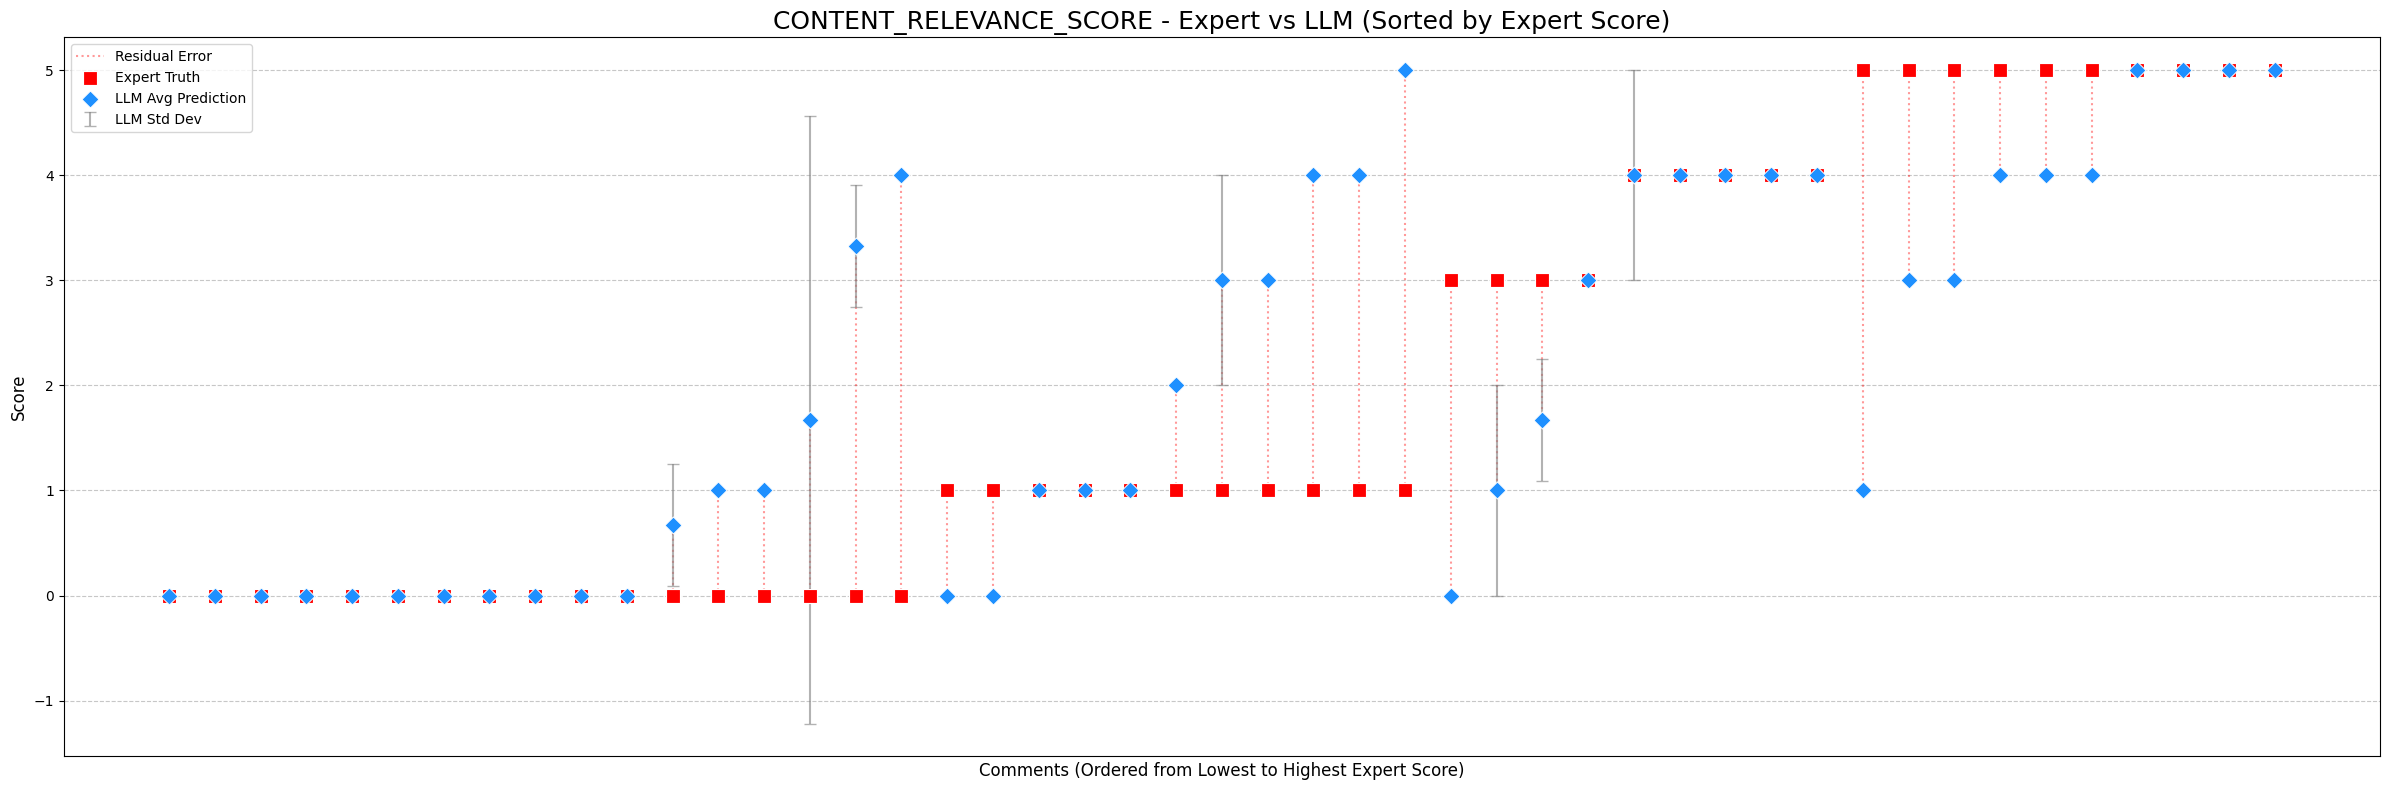

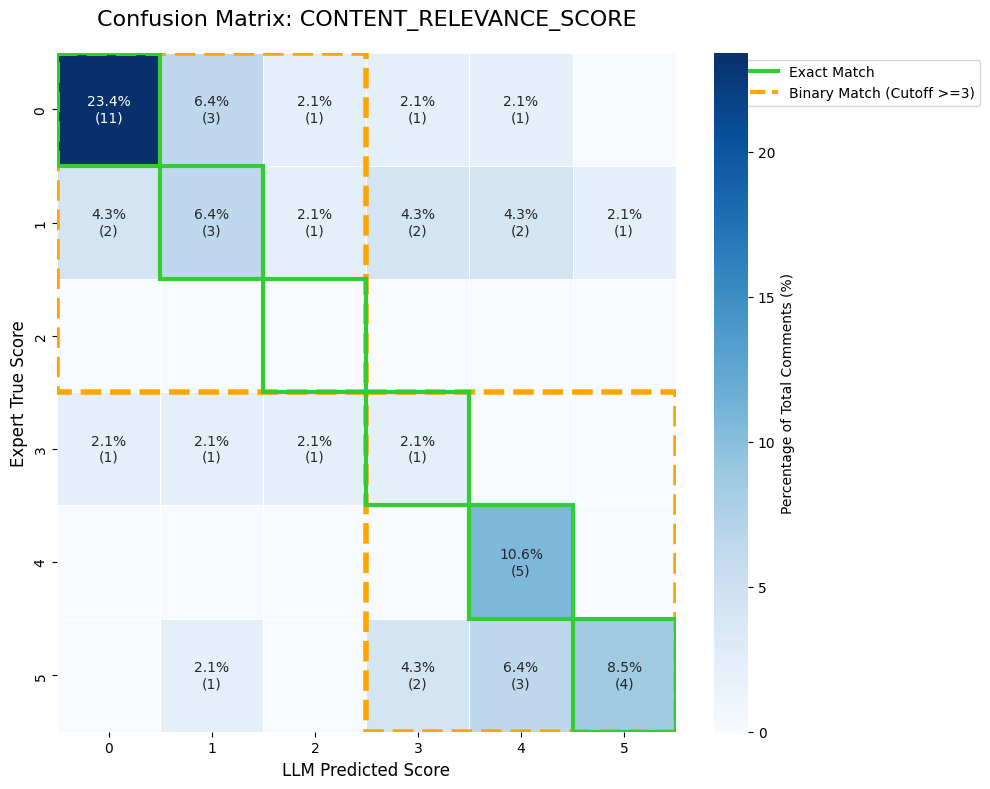

Exception: 'political_stance_score'
Exception: 'argument_quality_score'
Exception: 'sentiment_score'
Exception: 'discourse_tone_score'
Exception: 'dominant_frame_score'


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import numpy as np
import polars as pl
from sklearn.metrics import confusion_matrix

for feature_name in feature_names:

    try: 
        feature_type = FEATURE_CONFIG[feature_name]['type']
        
        # Deduplicamos para tener 1 fila por comment_id
        df_feat_unique = df_plot[feature_name].unique(subset=["comment_id"], keep="first", maintain_order=True)

        # =====================================================================
        # 1. VISUALIZACIONES PARA VARIABLES ORDINALES Y CONTINUAS
        # =====================================================================
        if feature_type in ['ordinal', 'continuous']:
            
            # --- A. SCATTER PLOT ORDENADO (Staircase Plot) ---
            df_sorted = df_feat_unique.sort([feature_name, "predicted_values_mean"]).with_row_index(name="plot_index")
            plt.figure(figsize=(24, 8))

            plot_idx = df_sorted["plot_index"].to_numpy()
            y_mean = df_sorted["predicted_values_mean"].to_numpy()
            y_std = df_sorted["predicted_values_std"].to_numpy()
            y_true = df_sorted[feature_name].to_numpy()

            # Variabilidad y Error
            plt.errorbar(x=plot_idx, y=y_mean, yerr=y_std, fmt='none', ecolor='gray', elinewidth=1.5, capsize=4, alpha=0.6, zorder=5, label='LLM Std Dev')
            plt.vlines(x=plot_idx, ymin=y_true, ymax=y_mean, colors='red', linestyles='dotted', alpha=0.4, linewidth=1.5, label='Residual Error')

            df_sns = df_sorted.to_pandas()
            sns.scatterplot(data=df_sns, x="plot_index", y=feature_name, color="red", s=110, marker="s", label="Expert Truth", zorder=10)
            sns.scatterplot(data=df_sns, x="plot_index", y="predicted_values_mean", color="dodgerblue", s=75, marker="D", label="LLM Avg Prediction", zorder=11)

            plt.title(f"{feature_name.upper()} - Expert vs LLM (Sorted by Expert Score)", fontsize=18)
            plt.xlabel("Comments (Ordered from Lowest to Highest Expert Score)", fontsize=12)
            plt.ylabel("Score", fontsize=12)
            plt.xticks([]) 
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.legend(loc='upper left')
            plt.tight_layout()
            plt.show()

            # --- B. MATRIZ DE CONFUSIÓN CON % Y CUADRANTES BINARIOS ---
            if feature_type == 'ordinal':
                y_true_cm = df_feat_unique[feature_name].cast(pl.Int32).to_list()
                y_pred_cm = df_feat_unique["predicted_values_mean"].round(0).cast(pl.Int32).to_list()
                
                classes = sorted(list(set(y_true_cm) | set(y_pred_cm)))
                cm = confusion_matrix(y_true_cm, y_pred_cm, labels=classes)
                cm_perc = (cm / np.sum(cm)) * 100
                
                # Anotaciones limpias (solo si > 0)
                annot_data = np.empty_like(cm, dtype=object)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        annot_data[i, j] = f"{cm_perc[i, j]:.1f}%\n({cm[i, j]})" if cm[i, j] > 0 else ""

                fig, ax = plt.subplots(figsize=(10, 8))
                sns.heatmap(cm_perc, annot=annot_data, fmt='', cmap='Blues', xticklabels=classes, yticklabels=classes,
                            linewidths=.5, cbar_kws={'label': 'Percentage of Total Comments (%)'}, ax=ax)
                
                # 1. Diagonal: Aciertos Puros
                for i in range(len(classes)):
                    ax.add_patch(patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='limegreen', lw=3, zorder=10))

                # 2. Cuadrantes: Aciertos Binarios (Basados en el cutoff)
                cutoff = FEATURE_CONFIG[feature_name].get('cutoff', 3) # Extraemos el cutoff, por defecto 3
                
                # Buscamos en qué índice de la matriz cae el cutoff
                split_idx = next((i for i, c in enumerate(classes) if c >= cutoff), None)
                
                if split_idx is not None and split_idx > 0:
                    # Caja de Verdaderos Negativos (< cutoff)
                    ax.add_patch(patches.Rectangle(
                        (0, 0), split_idx, split_idx, 
                        fill=False, edgecolor='orange', lw=4, ls='--', zorder=9
                    ))
                    # Caja de Verdaderos Positivos (>= cutoff)
                    ax.add_patch(patches.Rectangle(
                        (split_idx, split_idx), len(classes) - split_idx, len(classes) - split_idx, 
                        fill=False, edgecolor='orange', lw=4, ls='--', zorder=9
                    ))

                plt.title(f"Confusion Matrix: {feature_name.upper()}", fontsize=16, pad=20)
                plt.xlabel("LLM Predicted Score", fontsize=12)
                plt.ylabel("Expert True Score", fontsize=12)
                
                # Leyendas manuales
                pure_hit_line = mlines.Line2D([], [], color='limegreen', lw=3, label='Exact Match')
                binary_hit_line = mlines.Line2D([], [], color='orange', lw=3, linestyle='--', label=f'Binary Match (Cutoff >={cutoff})')
                ax.legend(handles=[pure_hit_line, binary_hit_line], loc='upper left', bbox_to_anchor=(1.1, 1))
                
                plt.tight_layout()
                plt.show()

        # =====================================================================
        # 2. VISUALIZACIONES PARA VARIABLES CATEGÓRICAS
        # =====================================================================
        elif feature_type == 'categorical':
            
            pred_col = "predicted_category_mode" 
            if pred_col in df_feat_unique.columns:
                try:
                    y_true_cat = df_feat_unique[feature_name].cast(pl.String).to_list()
                    y_pred_cat = df_feat_unique[pred_col].cast(pl.String).to_list()
                except AttributeError:
                    y_true_cat = df_feat_unique[feature_name].cast(pl.Utf8).to_list()
                    y_pred_cat = df_feat_unique[pred_col].cast(pl.Utf8).to_list()
                
                classes = sorted(list(set(y_true_cat) | set(y_pred_cat)))
                cm = confusion_matrix(y_true_cat, y_pred_cat, labels=classes)
                cm_perc = (cm / np.sum(cm)) * 100
                
                # Anotaciones limpias (solo si > 0)
                annot_data = np.empty_like(cm, dtype=object)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        annot_data[i, j] = f"{cm_perc[i, j]:.1f}%\n({cm[i, j]})" if cm[i, j] > 0 else ""

                fig, ax = plt.subplots(figsize=(12, 10))
                sns.heatmap(cm_perc, annot=annot_data, fmt='', cmap='Purples', xticklabels=classes, yticklabels=classes,
                            linewidths=.5, cbar_kws={'label': 'Percentage of Total Comments (%)'}, ax=ax)
                
                # Resaltar la diagonal principal (Aciertos en clases categóricas)
                for i in range(len(classes)):
                    ax.add_patch(patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='limegreen', lw=3, zorder=10))

                plt.title(f"Categorical Confusion Matrix: {feature_name.upper()}", fontsize=16, pad=20)
                plt.xlabel("LLM Predicted Category", fontsize=12)
                plt.ylabel("Expert True Category", fontsize=12)
                plt.xticks(rotation=45, ha='right')
                
                pure_hit_line = mlines.Line2D([], [], color='limegreen', lw=3, label='Exact Match')
                ax.legend(handles=[pure_hit_line], loc='upper left', bbox_to_anchor=(1.1, 1))
                
                plt.tight_layout()
                plt.show()
    except Exception as e:
        print(f"Exception: {e}")        

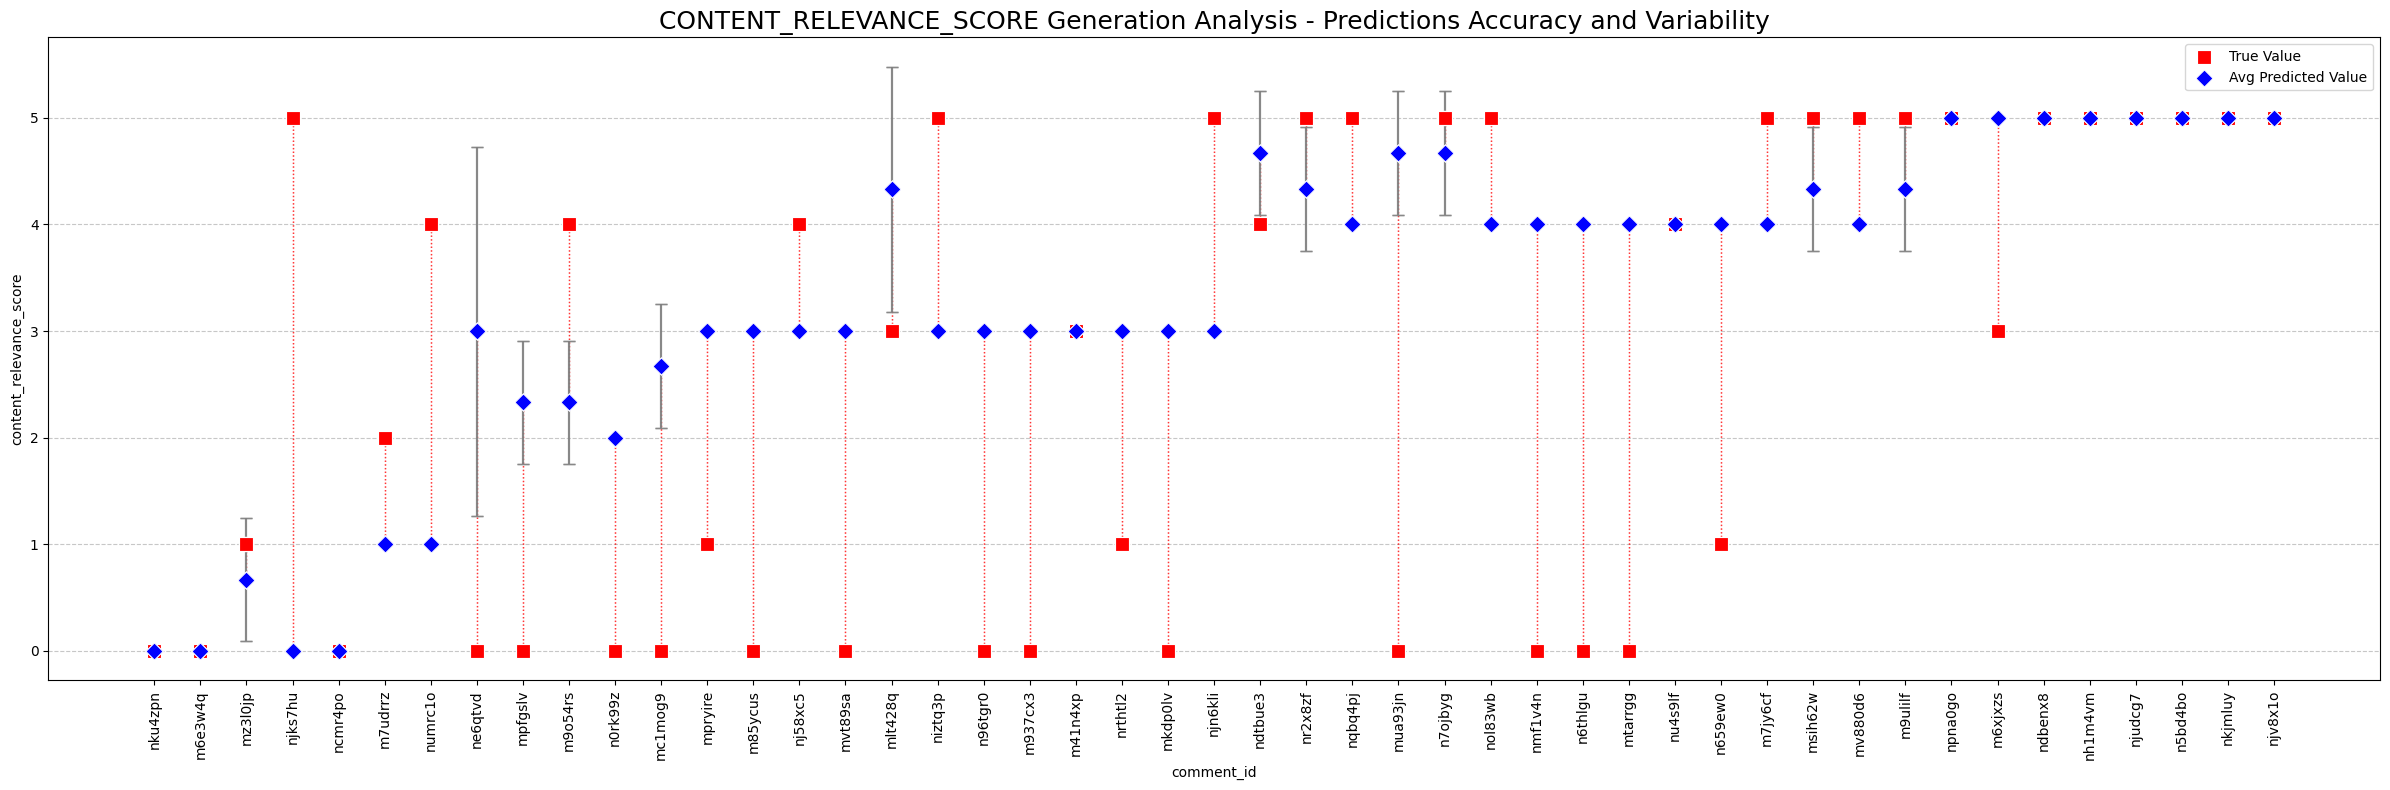

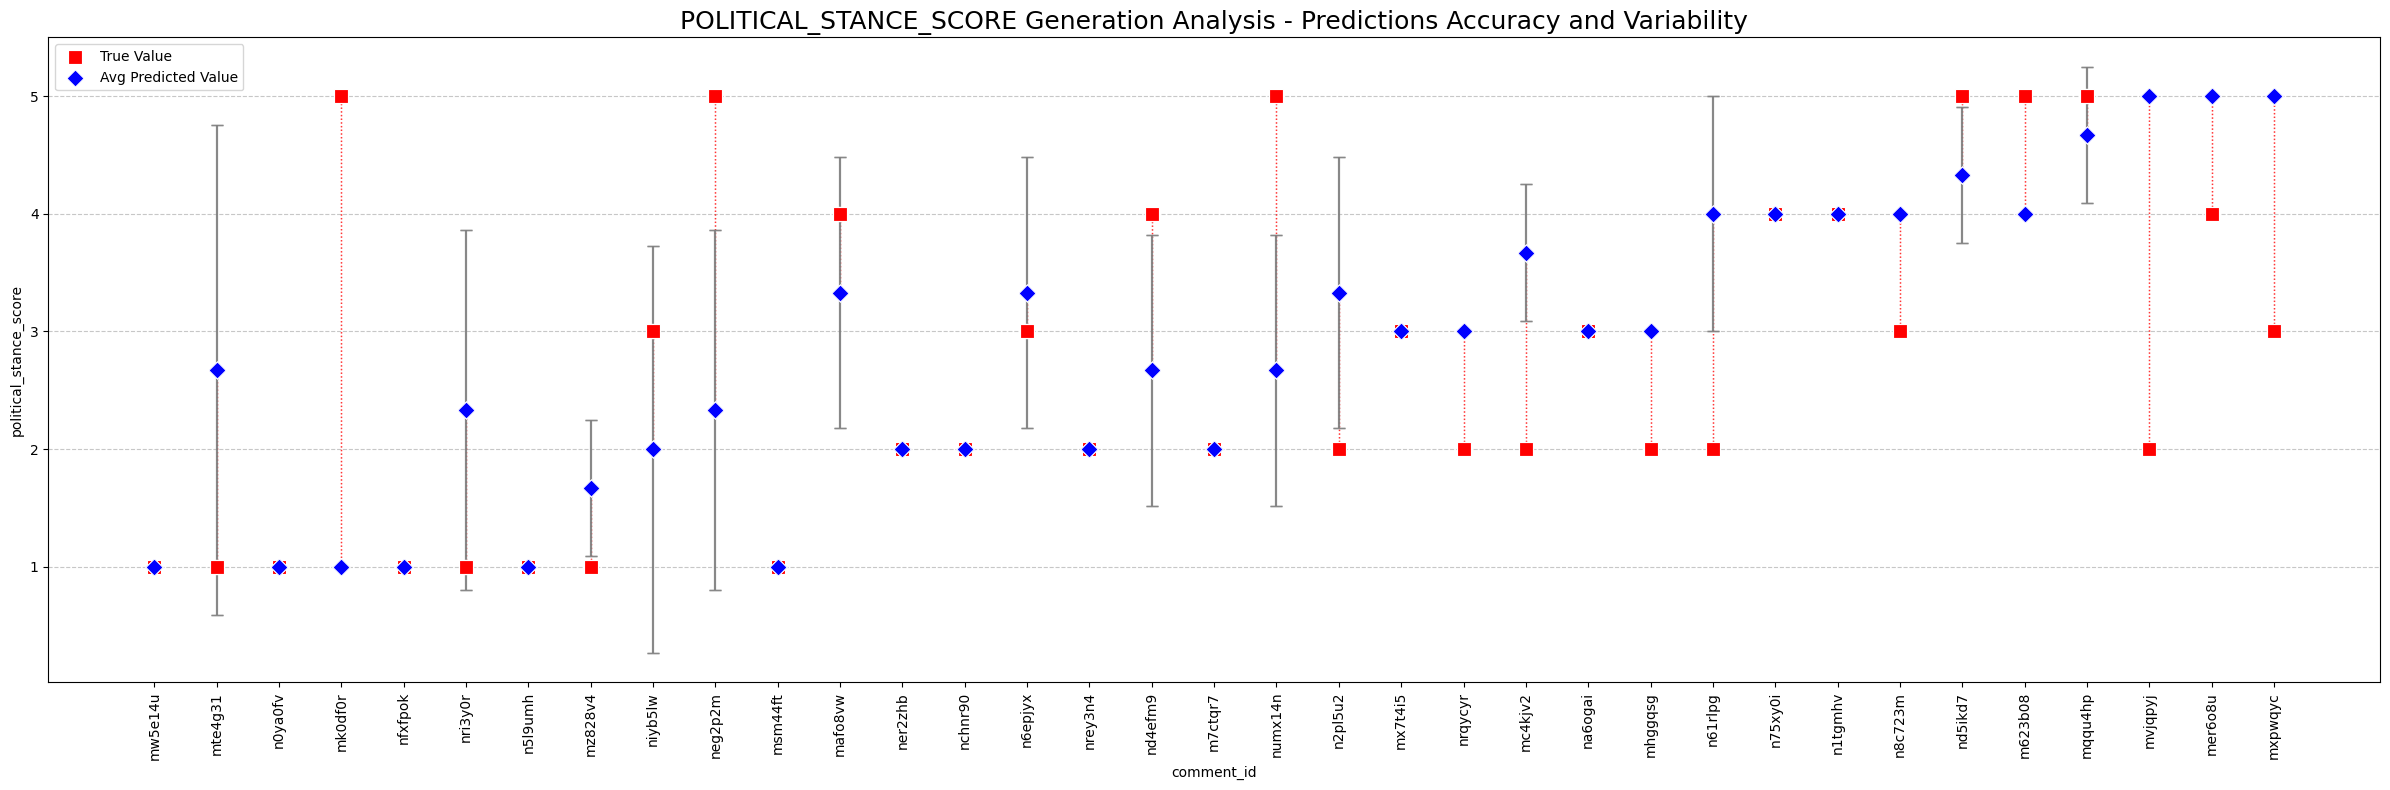

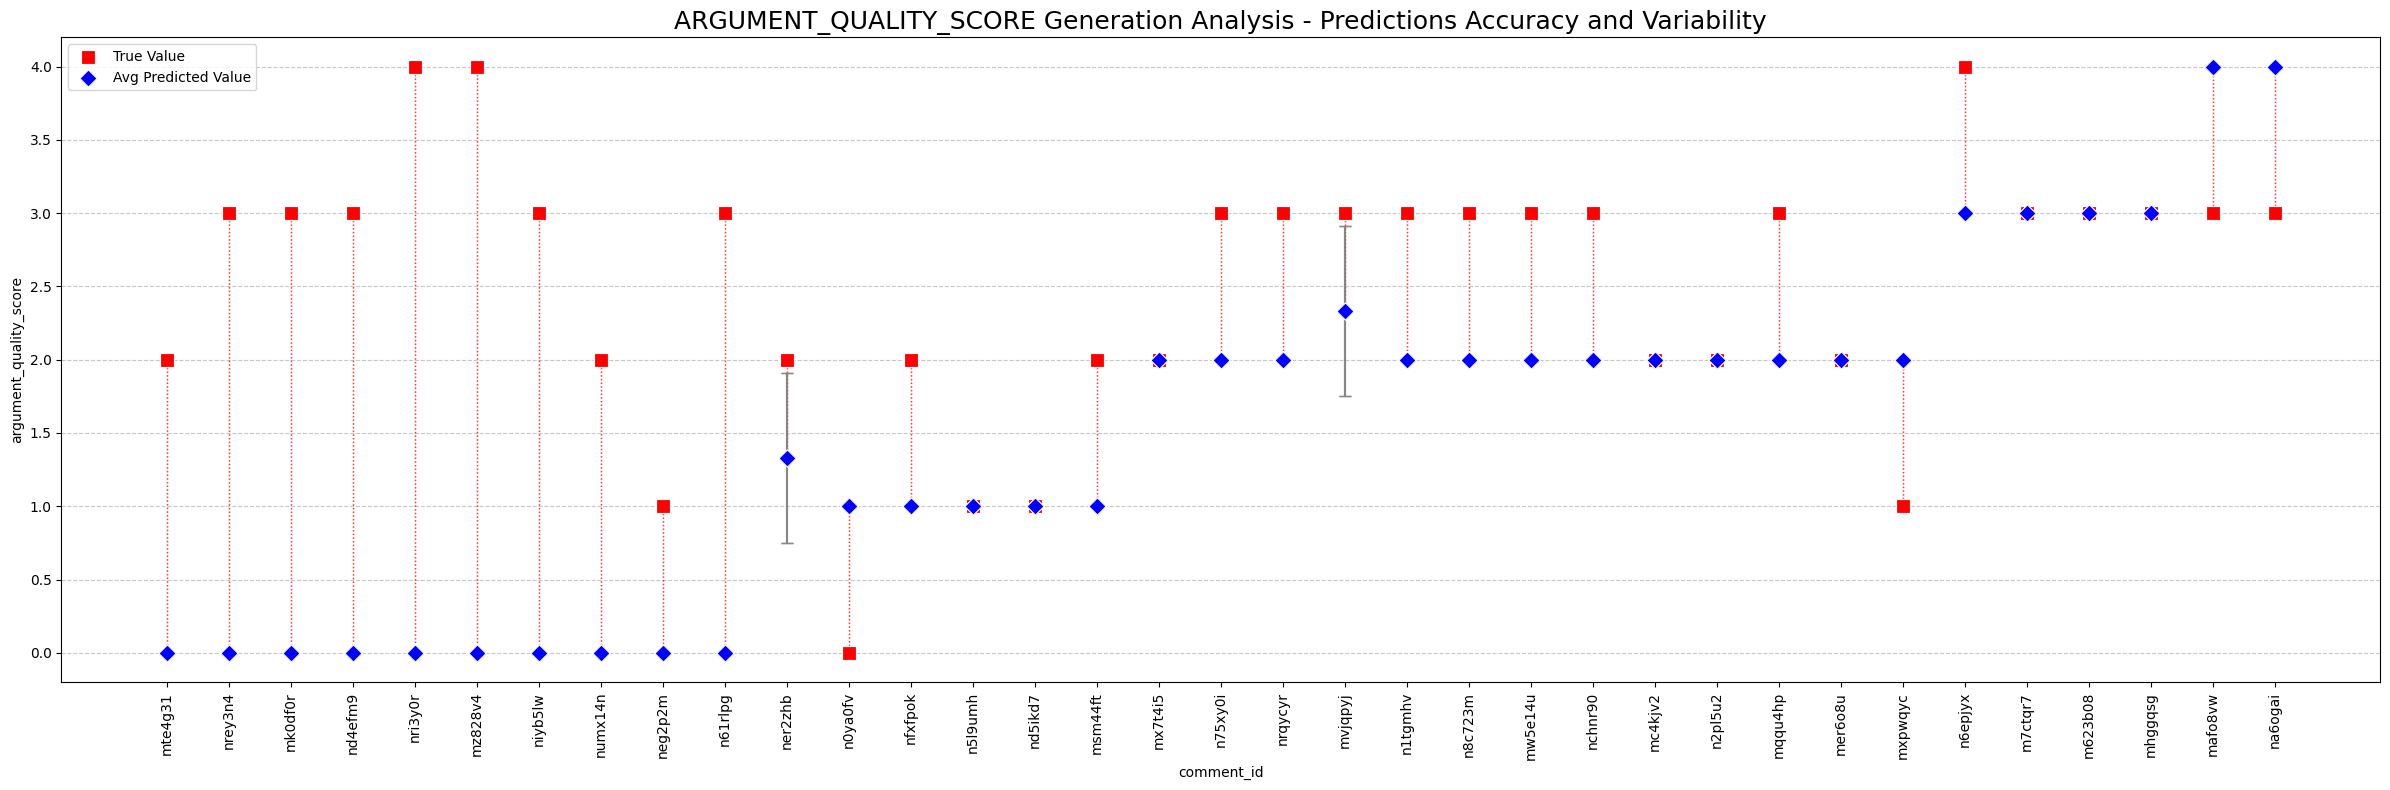

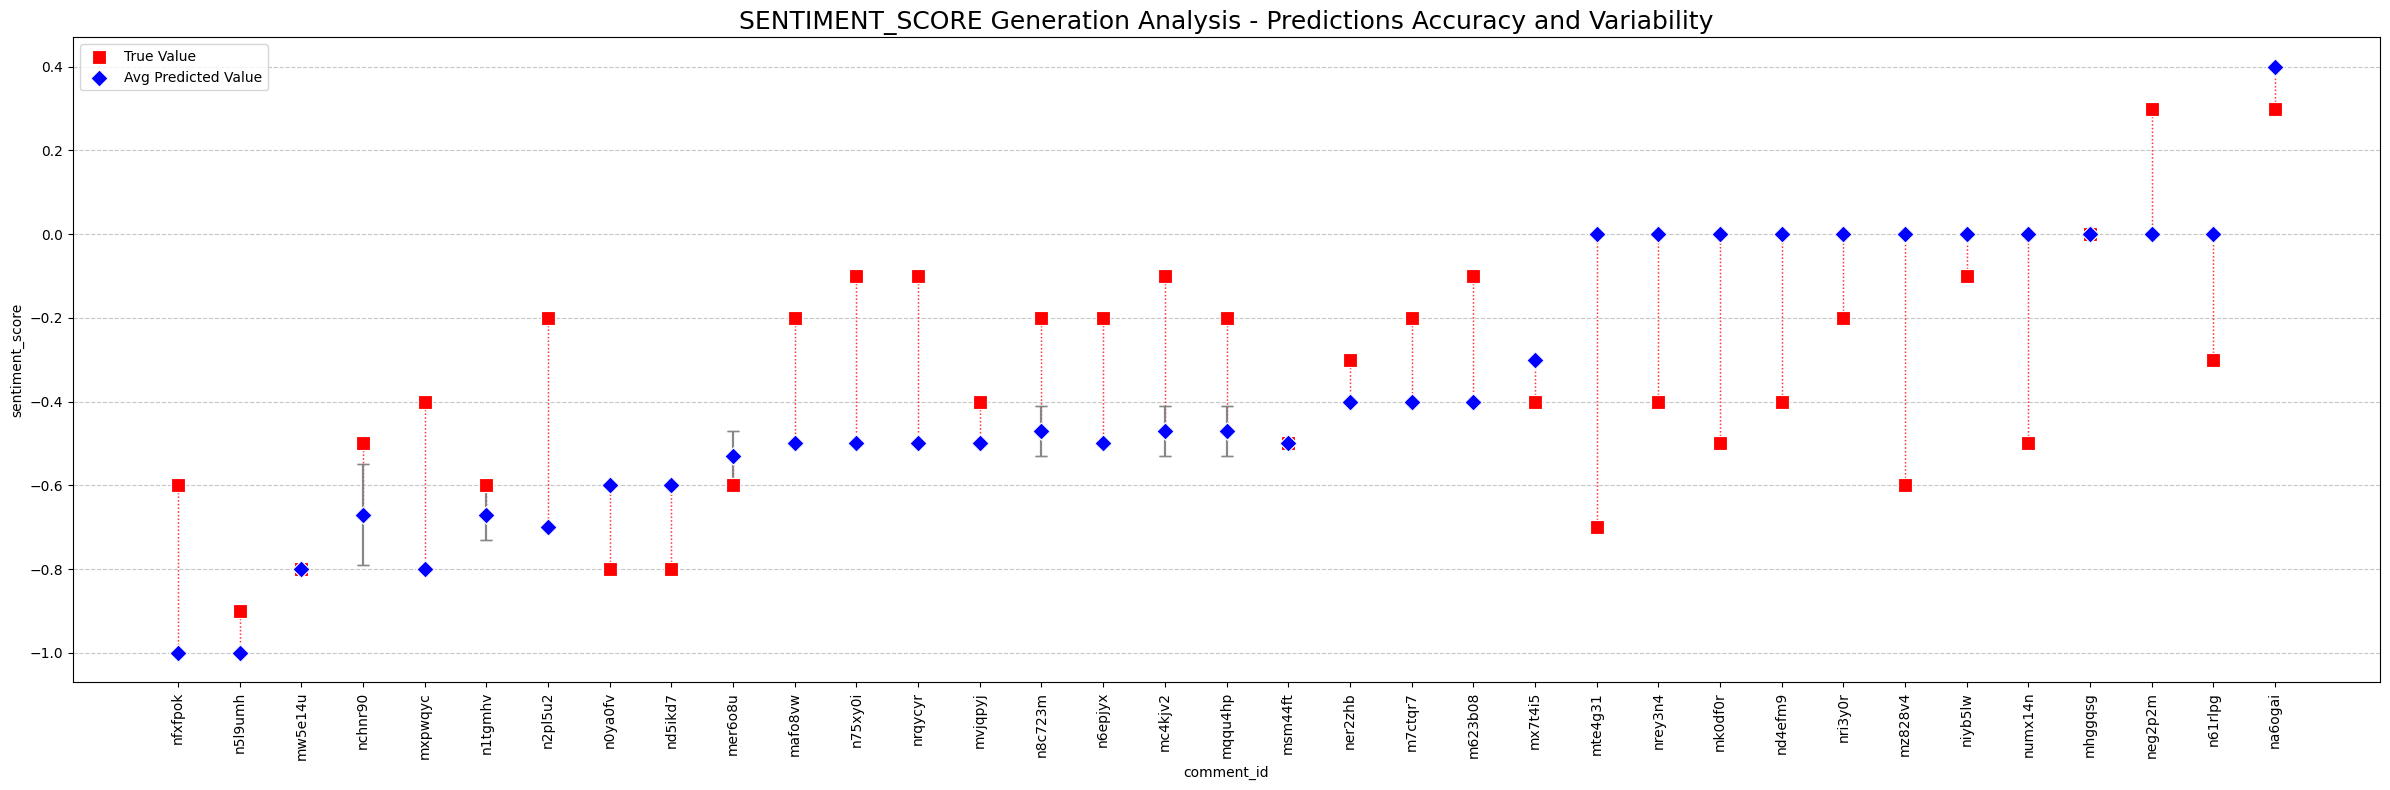

In [101]:
for feature_name in feature_names:

    feature_type = FEATURE_CONFIG[feature_name]['type']

    if feature_type in ['ordinal', 'continuous']:

        plt.show()

        plt.figure(figsize=(24, 8))

        # C. "Ground Truth" (El valor real - PUNTO ROJO)
        sns.scatterplot(
            data=df_plot[feature_name],
            x="comment_id",
            y=feature_name,
            color="red",
            s=110,            # Tamaño grande
            marker="s",       # Forma de diamante
            label="True Value",
            zorder=10         # Para que aparezca encima de todo
        )

        plt.errorbar(
            x=df_plot[feature_name]["comment_id"],             # Misma X
            y=df_plot[feature_name]["predicted_values_mean"],  # Misma Y (centro de la barra)
            yerr=df_plot[feature_name]["predicted_values_std"],# <--- AQUÍ VA LA LONGITUD DE LA BARRA (STD)
            fmt='none',      # 'none' significa: "no dibujes puntos, solo las líneas"
            ecolor='gray',   # Color de la barra (gris para no distraer)
            elinewidth=1.5,  # Grosor de la línea
            capsize=4,       # "Topes" horizontales en los extremos de la barra
            alpha=0.6,       # Transparencia
            zorder=5         # Nivel de capa (detrás de los puntos del scatter)
        )

        sns.scatterplot(
            data=df_plot[feature_name],
            x="comment_id",
            y="predicted_values_mean",
            color="blue",
            s=75,            # Tamaño grande
            marker="D",       # Forma de diamante
            label="Avg Predicted Value",
            zorder=10         # Para que aparezca encima de todo
        )

        plt.vlines(
            x=df_plot[feature_name]["comment_id"],
            ymin=df_plot[feature_name][feature_name],
            ymax=df_plot[feature_name]["predicted_values_mean"],
            colors='red',
            linestyles='dotted',
            alpha=0.4,
            linewidth=1,
            label='Residual Error'
        )

        plt.title(f"{feature_name.upper()} Generation Analysis - Predictions Accuracy and Variability", fontsize=18)
        plt.xticks(rotation=90, fontsize=10) # Rotar etiquetas 90 grados
        plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla horizontal para ver mejor los niveles
        plt.tight_layout()

        plt.show()

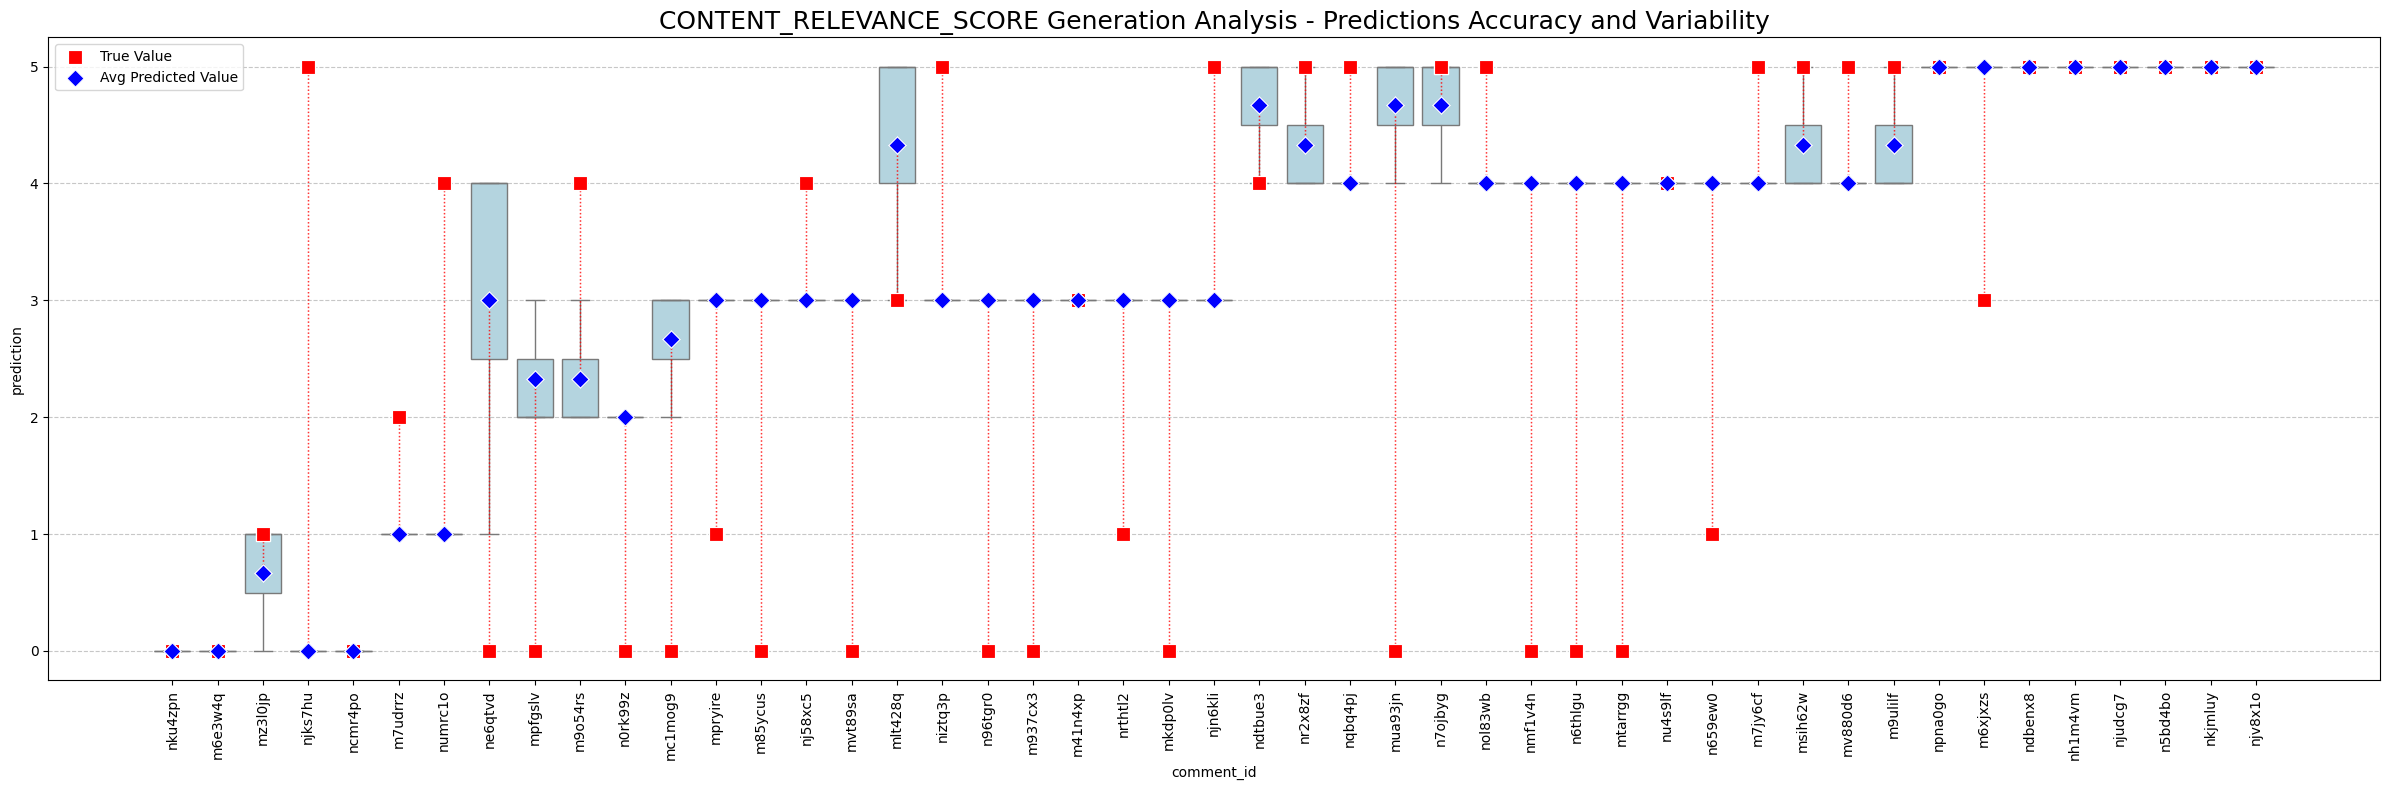

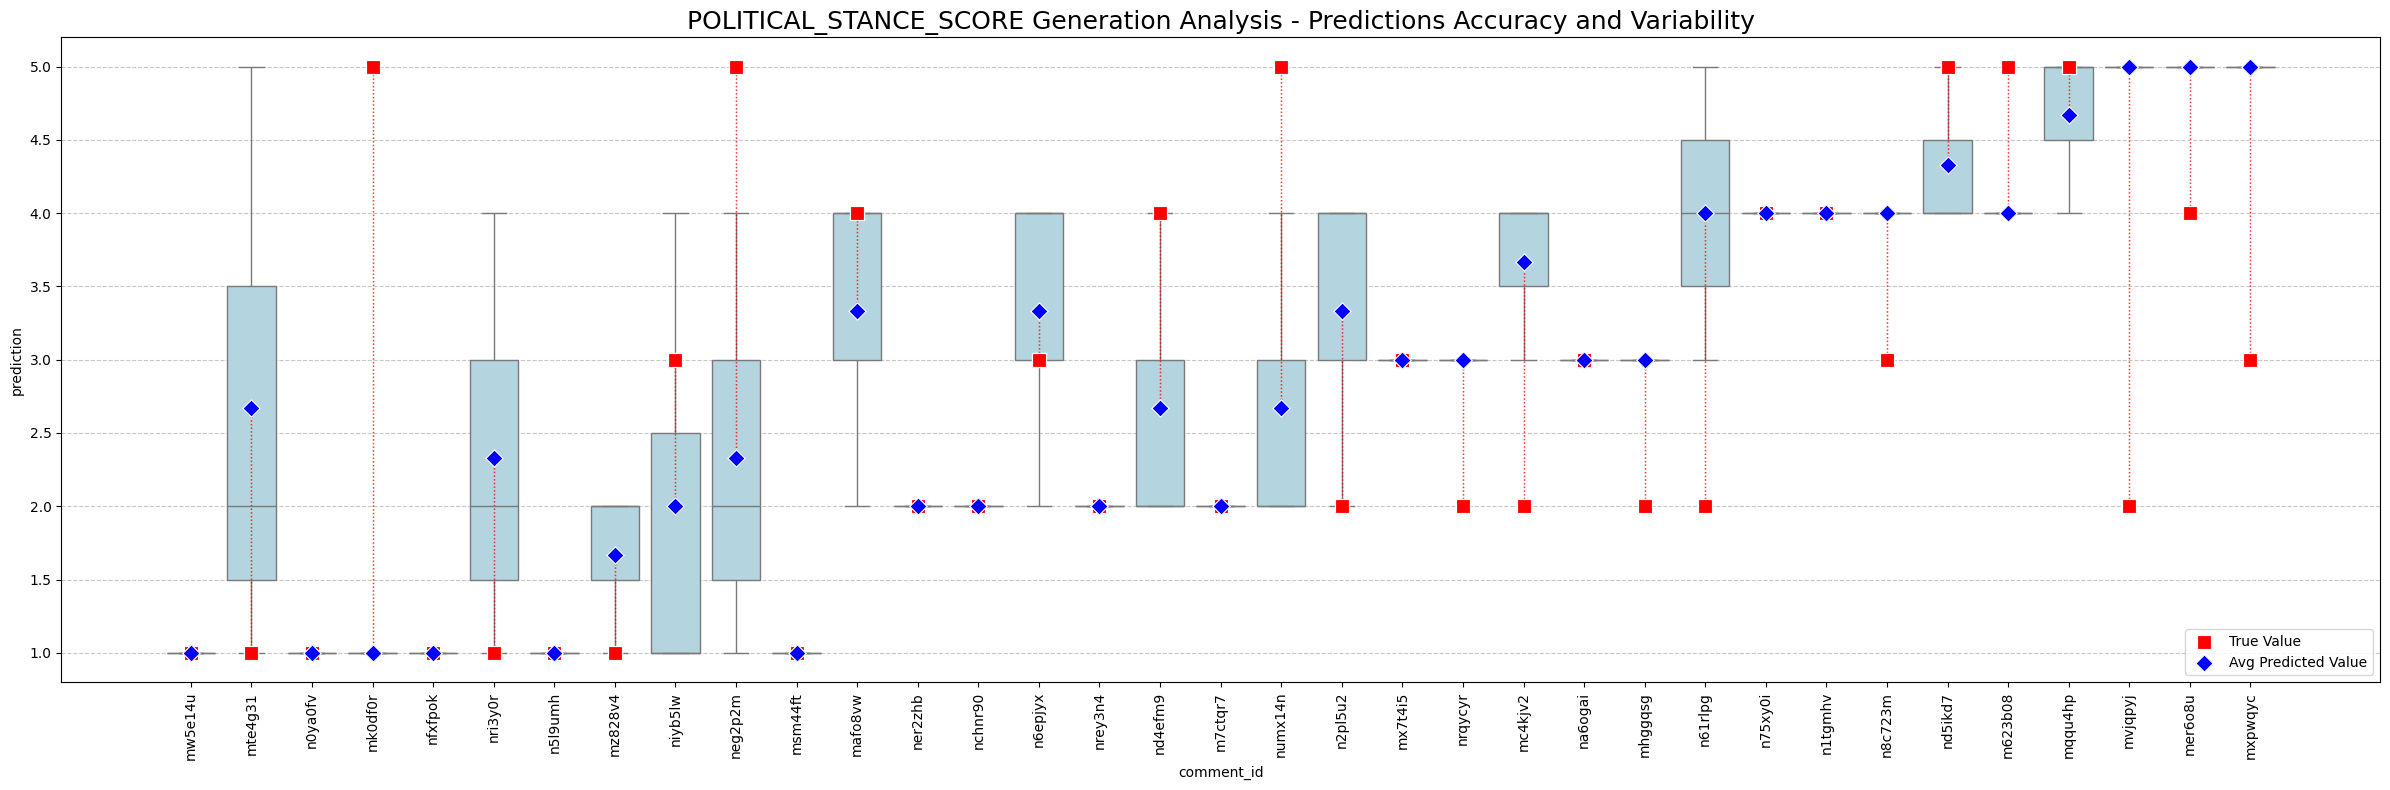

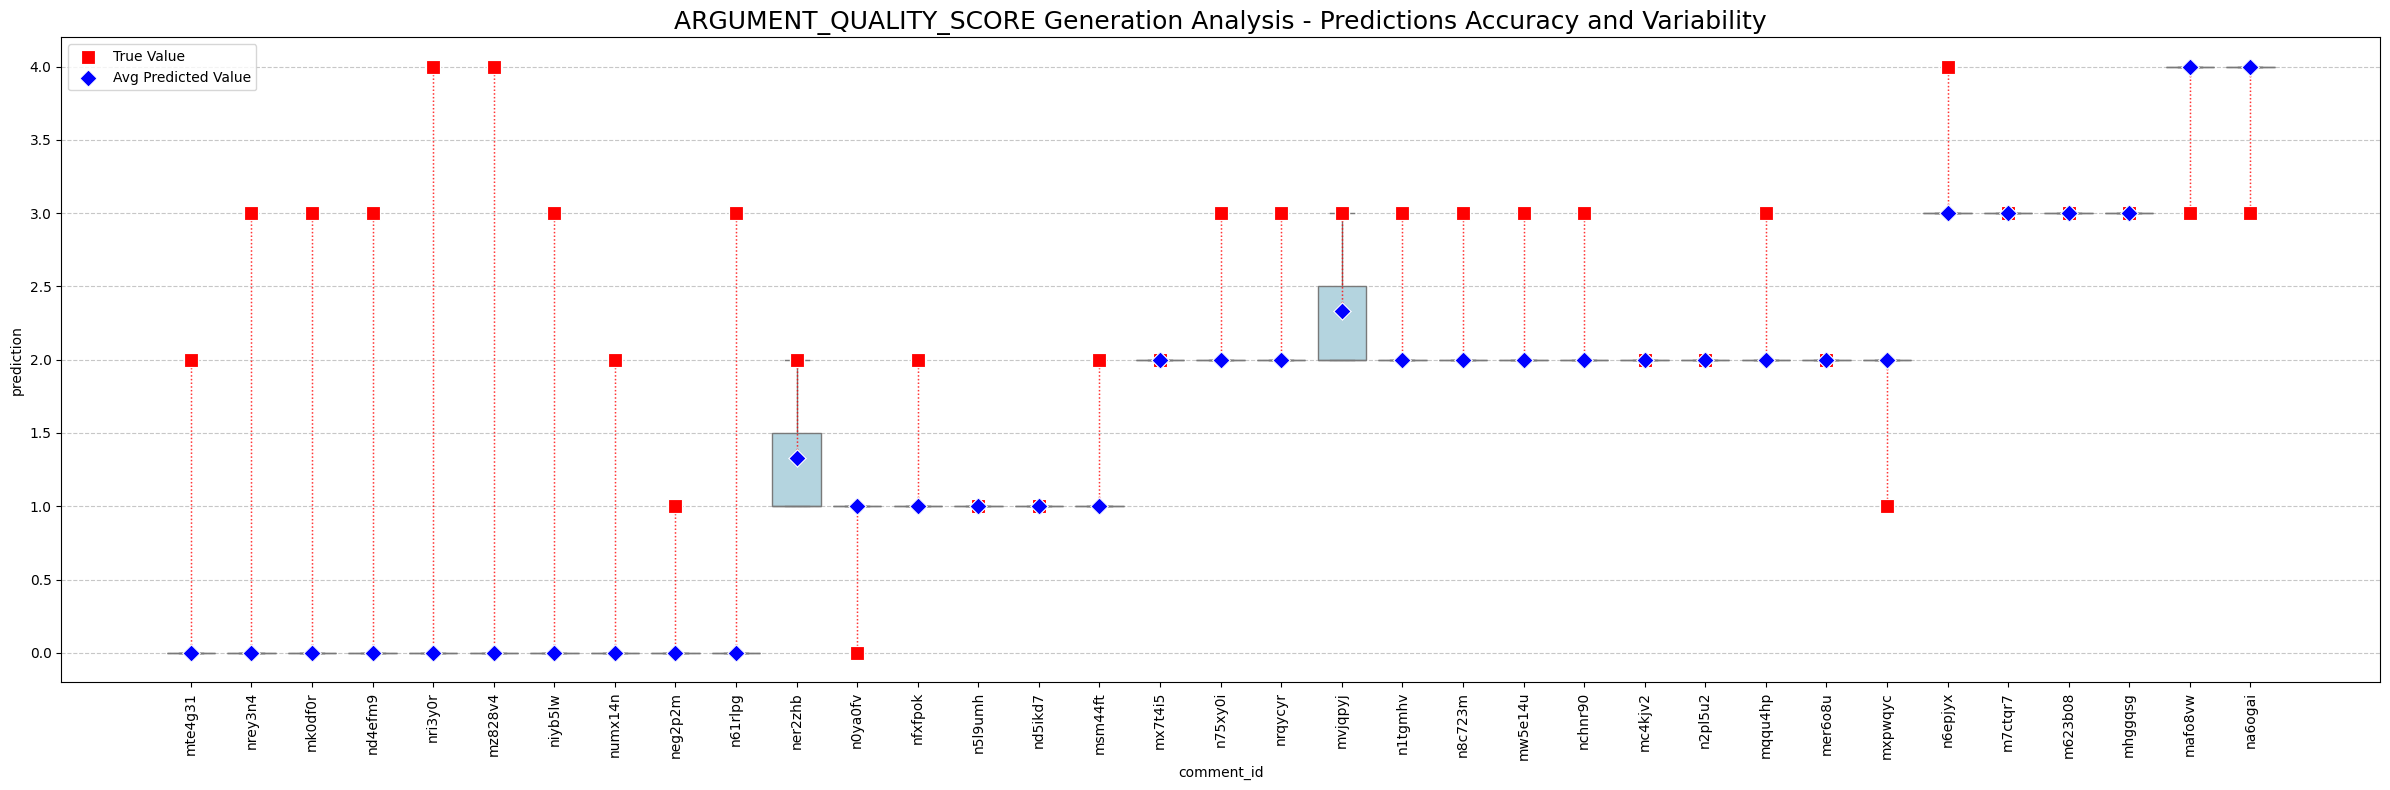

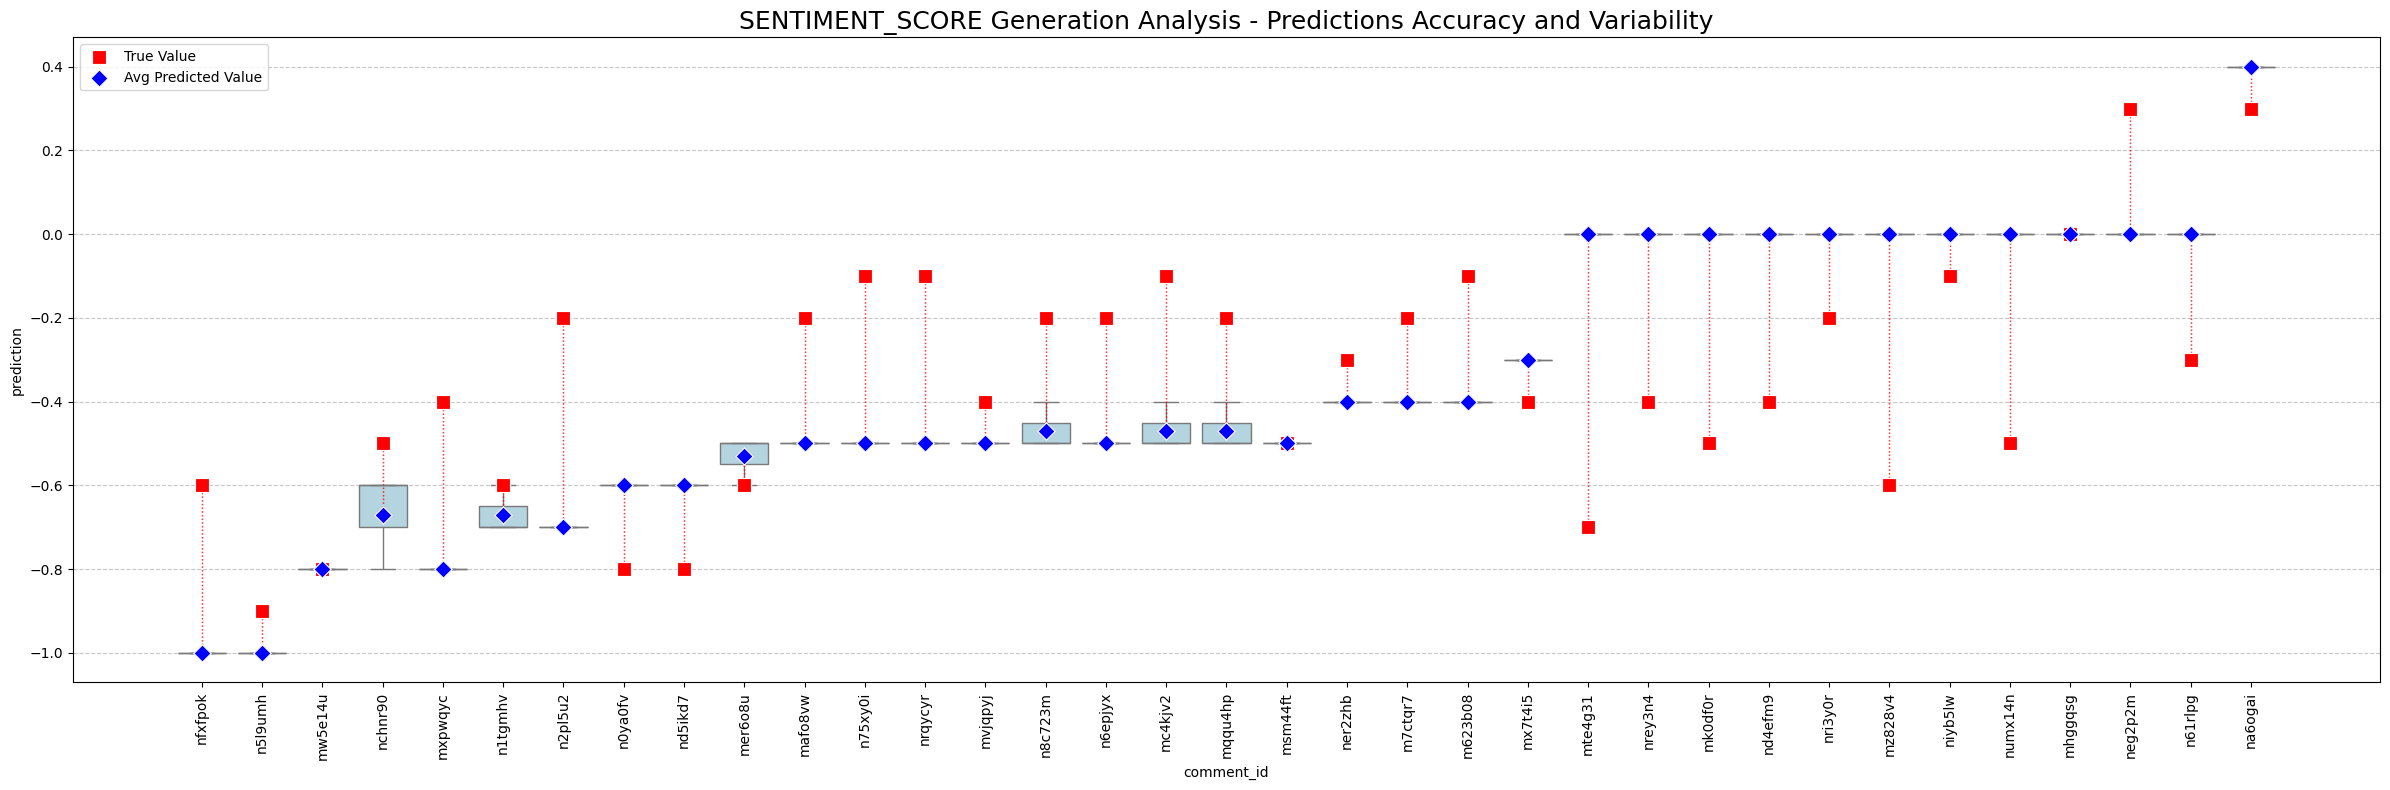

In [102]:
for feature_name in feature_names:

    feature_type = FEATURE_CONFIG[feature_name]['type']

    if feature_type in ['ordinal', 'continuous']:

        plt.figure(figsize=(24, 8))

        # A. Boxplot de las Predicciones (Ordenado)
        sns.boxplot(
            data=df_plot[feature_name],
            x="comment_id",
            y="prediction",
            color="lightblue",
            showfliers=True
        )

        # C. "Ground Truth" (El valor real - PUNTO ROJO)
        sns.scatterplot(
            data=df_plot[feature_name],
            x="comment_id",
            y=feature_name,
            color="red",
            s=110,            # Tamaño grande
            marker="s",       # Forma de diamante
            label="True Value",
            zorder=10         # Para que aparezca encima de todo
        )

        sns.scatterplot(
            data=df_plot[feature_name],
            x="comment_id",
            y="predicted_values_mean",
            color="blue",
            s=75,            # Tamaño grande
            marker="D",       # Forma de diamante
            label="Avg Predicted Value",
            zorder=10         # Para que aparezca encima de todo
        )

        plt.vlines(
            x=df_plot[feature_name]["comment_id"],
            ymin=df_plot[feature_name][feature_name],
            ymax=df_plot[feature_name]["predicted_values_mean"],
            colors='red',
            linestyles='dotted',
            alpha=0.4,
            linewidth=1,
            label='Residual Error'
        )

        plt.title(f"{feature_name.upper()} Generation Analysis - Predictions Accuracy and Variability", fontsize=18)
        plt.xticks(rotation=90, fontsize=10) # Rotar etiquetas 90 grados
        plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla horizontal para ver mejor los niveles
        plt.tight_layout()

**TO DO:**

- Añadir la avg error score en los graficos anteriores, obtenida promediando los error score de las iteraciones de las validaciones individuales. 

- Añadir grafico de variabilidad para las features categoricas (discourse_tone_score, dominant_frame_score)